# Data Analytics II — Logistic Regression on Social Network Ads

**Objective:**
1. Implement Logistic Regression to classify whether a user will purchase a product.
2. Compute the Confusion Matrix and derive: TP, FP, TN, FN, Accuracy, Error Rate, Precision, Recall.

**Dataset:** Social_Network_Ads.csv — 400 users with Age, EstimatedSalary, Gender, and Purchased (0 = No, 1 = Yes).

### Logistic Regression (quick concept)
Unlike Linear Regression which predicts a *number*, Logistic Regression predicts a *probability* between 0 and 1, then classifies the result as either class 0 or class 1 using a threshold (default 0.5). It uses the **sigmoid function** to squash any input into that 0–1 range.


Sure — here's a detailed plain-English walkthrough of what the Logistic Regression notebook actually does and why each step matters.

---

## Data Analytics II — Logistic Regression on Social Network Ads

**Big picture:** This is the second predictive-modeling notebook in the series. The Boston Housing notebook predicted a *number* (house price) — that's called **regression**. This notebook predicts a *category* — will this user click "buy" or not? That's called **classification**. Different problem, different math, different evaluation metrics, but the overall workflow is similar.

The business scenario: a social network is running an ad campaign for a high-end product. They have records of 400 users — their age, their estimated salary, and whether each one ended up purchasing the advertised product. We want to build a model that, given a new user's age and salary, can predict whether *they* will purchase. If we can do this well, the company can target ads only at users who are likely to buy, saving money and boosting conversion rates.

---

### Linear Regression vs Logistic Regression — what's actually different?

This is the most important conceptual distinction in this notebook, so it's worth spelling out clearly.

**Linear Regression** answers questions like *"How much?"* — given some features, predict a continuous number. House prices, temperature, salary — anything where the answer is a quantity on a real-valued scale.

**Logistic Regression** answers questions like *"Which category?"* — given some features, predict which of two (or more) classes something belongs to. Will the user click? Is the email spam? Is the tumor malignant? — anything where the answer is a label.

Despite the confusing name, **logistic regression is a classification algorithm, not a regression algorithm.** The "regression" in its name is a historical artifact from how the math was originally derived.

**How does it work under the hood?** It does two things:

1. First, it computes a number using the same kind of weighted-sum formula linear regression uses: `b₀ + b₁·age + b₂·salary`. This number can be anything — positive, negative, large, small.
2. Then it squashes that number through the **sigmoid function** — an S-shaped curve that maps any real number into the range 0 to 1. This squashed value is interpreted as a probability.
3. Finally, it applies a threshold (default 0.5): if the probability is above 0.5, predict class 1 ("will purchase"); below 0.5, predict class 0 ("won't purchase").

So linear regression draws a *straight line through the data*; logistic regression draws an *S-shaped curve* that smoothly transitions from 0 to 1 — and that curve represents the probability of belonging to class 1.

---

### What we did, step by step:

1. **Brought in our toolbox** — Loaded our usual libraries (pandas, numpy, plotting), and from scikit-learn we pulled in:
   - The **train/test splitter** — same as before.
   - **StandardScaler** — a feature-scaling tool we'll explain in step 5.
   - **LogisticRegression** — the classifier itself.
   - A bundle of **classification metrics** — confusion matrix, accuracy, precision, recall, and the all-in-one classification report.

2. **Loaded the dataset** — Read the Social Network Ads CSV: 400 users, 5 columns. Three of those columns matter for prediction (Age, EstimatedSalary, and the target Purchased); User ID is just a unique identifier and Gender we set aside for simplicity.

3. **Sanity-checked the data** — Confirmed there were no missing values, and crucially, **checked the class balance** — how many users purchased versus didn't. This came out roughly 268/132 (about 67% non-purchasers, 33% purchasers). Class balance matters: if 99% of users didn't buy, a "lazy" model that always predicts "no" would be 99% accurate but useless. Our split is reasonable, so we don't need special techniques.

4. **Separated features and target:**
   - **X** = Age and EstimatedSalary (the two features the model uses to predict).
   - **y** = Purchased (0 or 1 — what we're trying to predict).

5. **Split into training and testing sets** — Same principle as the regression notebook: never test a model on data it has trained on. We held out 25% of the users as a test set the model would never see during training.

6. **Scaled the features — and this step is critical for logistic regression.**
   
   **The problem:** Age values range from about 18 to 60 (a span of ~40). EstimatedSalary values range from 15,000 to 150,000 (a span of ~135,000). The salary numbers are literally thousands of times bigger than the age numbers.
   
   **Why this matters:** Logistic regression learns weights for each feature that combine multiplicatively. If salary's raw magnitude is 2,000× larger than age's, the model's optimization process gets dominated by salary purely because of its scale — not because salary is genuinely more predictive. The model takes much longer to converge, and small changes in age effectively get drowned out.
   
   **The fix — StandardScaler:** We rescaled both columns so each one has a mean of 0 and a standard deviation of 1. Now Age and Salary are on the same playing field — a "1 unit" change in either one represents the same statistical magnitude.
   
   **One subtle but important detail:** We *fit* the scaler on the training data only (it learns the mean and standard deviation from training), and then we *apply* those same numbers to the test data. We do **not** fit a separate scaler on the test set. Why? Because in real life, when you deploy this model and a brand-new user shows up, you don't know what "the mean salary" is — you only know what it was when you trained. Re-fitting on the test set would be a form of *data leakage* that makes test results look artificially good.

7. **Trained the model** — Fed the scaled training features and the labels (0/1) to the LogisticRegression object, which figured out the best weights — one for age, one for salary, plus an intercept. The math behind this isn't simple linear algebra like for linear regression; it uses an iterative optimization method called *maximum likelihood estimation*, which essentially asks: "what coefficient values make the observed data most probable?" But scikit-learn handles all of this internally — we just call `.fit()`.

8. **Made predictions on the test set** — For each of the 100 held-out test users, the model output either 0 or 1. We compared the predictions side-by-side with the actual labels for the first 15 users to get an intuitive sense of how well it did.

---

### Step 9: The Confusion Matrix — the heart of classification evaluation

This is *the* fundamental tool for evaluating classifiers, and it deserves a careful explanation because the rest of the notebook is built on it.

When a classifier makes a prediction, there are exactly four possible outcomes:

|                       | Model predicted **No (0)** | Model predicted **Yes (1)**  |
|-----------------------|----------------------------|------------------------------|
| **Actually No (0)**   | True Negative (TN) ✅       | False Positive (FP) ❌        |
| **Actually Yes (1)**  | False Negative (FN) ❌      | True Positive (TP) ✅         |

- **True Positive (TP)** — Model said "yes", actual was "yes". The user was going to buy, and the model correctly flagged them. We sent them an ad, they purchased — money made.

- **True Negative (TN)** — Model said "no", actual was "no". The user wasn't going to buy, and the model correctly skipped them. We didn't waste an ad on them — money saved.

- **False Positive (FP)** — Model said "yes", actual was "no". This is a **false alarm** — also called a **Type I error**. We targeted them with an ad but they didn't buy. Wasted ad spend.

- **False Negative (FN)** — Model said "no", actual was "yes". This is a **miss** — also called a **Type II error**. The user *was* going to buy but we didn't show them the ad. Lost revenue opportunity.

Our test set produced this confusion matrix:
- TN = 62 (correctly predicted no-purchase)
- FP = 6 (false alarms)
- FN = 10 (missed buyers)
- TP = 22 (correctly predicted purchases)

Total test users = 100. Total correct = 62 + 22 = 84. Total wrong = 6 + 10 = 16.

We also drew it as a heatmap because the visual layout makes it easier to digest at a glance — diagonal cells (correct predictions) should be dark, off-diagonal cells (errors) should be light.

---

### Step 10: Deriving Performance Metrics from the Confusion Matrix

The four numbers in the confusion matrix are everything — every standard metric is just a different ratio computed from those four cells.

**Accuracy = (TP + TN) / Total** → **84%**
> "Out of all 100 predictions, how many were correct?" 84 of 100 — that's our headline score. *But here's the catch:* accuracy can be misleading when classes are imbalanced. If 95% of users never buy, a model that always predicts "no" would have 95% accuracy and be completely useless. Always check class balance before trusting accuracy alone.

**Error Rate = (FP + FN) / Total = 1 − Accuracy** → **16%**
> Just the inverse of accuracy. 16% of our predictions were wrong.

**Precision = TP / (TP + FP)** → **0.79 (78.6%)**
> "Of all the times the model said 'yes', how often was it actually 'yes'?" In our case: of the 28 users we flagged as likely buyers (22 TP + 6 FP), 22 actually bought — about 79%. **Precision matters when false alarms are expensive.** If each ad costs you $10 and a wrong target wastes that money, precision tells you how much of your ad spend goes to genuine prospects.

**Recall = TP / (TP + FN)** → **0.69 (68.8%)**
> "Of all the actual 'yes' cases, how many did the model catch?" In our case: of the 32 users who actually bought (22 TP + 10 FN), the model caught 22 — about 69%. **Recall matters when missing positives is expensive.** If failing to target a likely buyer means losing a $500 sale, recall tells you what fraction of the available revenue you're capturing.

**The precision-recall trade-off:** These two metrics often pull in opposite directions. If you make the model trigger-happy ("predict yes more often"), you'll catch more buyers (high recall) but waste ads on more non-buyers (low precision). If you make it conservative, you'll skip wasted ads (high precision) but miss many actual buyers (low recall). The right balance depends on the *business cost* of each kind of mistake.

We also cross-checked our manual calculations against scikit-learn's built-in functions — the numbers matched exactly, which confirms we understood the formulas correctly. That's a useful habit for the viva: knowing how to compute these by hand from the confusion matrix, *and* knowing the shortcut function.

Finally, we printed a **classification report**, which is a tidy table showing precision, recall, and F1-score for *both* classes (not just the positive one) along with totals. F1 is the harmonic mean of precision and recall — a single number that punishes you when either precision or recall is low, useful when you want one combined score instead of two separate ones.

---

### How this notebook fits into the bigger picture

In the project pipeline:

- **Data Wrangling I & II** — clean and prepare the data structurally and statistically.
- **Descriptive Statistics** — understand the data before modeling.
- **Linear Regression (Boston Housing)** — predict a *number*. Evaluate with MAE, MSE, RMSE, R². Plot residuals.
- **Logistic Regression (this notebook)** — predict a *category*. Evaluate with confusion matrix, accuracy, precision, recall. Visualize with a heatmap.

These two — linear and logistic regression — are the two foundational supervised-learning algorithms. Almost every more advanced ML technique (decision trees, random forests, neural networks, gradient boosting) is in some sense an extension or generalization of one or both of them. Mastering the workflow on these two — split → scale → fit → predict → evaluate — gives you the template for *every* future modeling task. The model object changes; the workflow stays the same.

**One more thing worth knowing for the viva:** in this assignment we used a default classification threshold of 0.5 — anything with predicted probability above 0.5 gets labeled "yes." But you can tune that threshold to favor precision or recall. Lower the threshold (say to 0.3) and the model flags more users as buyers — recall goes up, precision goes down. Raise the threshold (say to 0.7) and the model becomes more conservative — precision goes up, recall goes down. This threshold isn't part of the training process; it's a business decision you make after the model is trained.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — plotting
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split — split data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler — scales features to mean=0, std=1 (important for logistic regression)
from sklearn.preprocessing import StandardScaler

# LogisticRegression — the classifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, classification_report)

%matplotlib inline

## Step 2: Load the Dataset

In [4]:
# Load the Social Network Ads dataset
df = pd.read_csv('Logistic_Regression_V.csv')

print("Shape:", df.shape)
df.head()

Shape: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,41,71570,1
1,15624511,Female,28,16015,0
2,15624512,Male,25,76813,0
3,15624513,Male,53,42712,1
4,15624514,Male,55,115497,1


In [5]:
# Check column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [6]:
# Summary statistics
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.562471e+07,39.712500,83234.690000,0.330000
std,1.156143e+02,11.883091,40206.843843,0.470802
min,1.562451e+07,18.000000,15126.000000,0.000000
25%,1.562461e+07,29.000000,51322.750000,0.000000
50%,1.562471e+07,41.000000,82694.500000,0.000000
75%,1.562481e+07,50.000000,118984.750000,1.000000
max,1.562491e+07,60.000000,149869.000000,1.000000


In [7]:
# Class balance — how many bought vs did not buy
# Purchased = 0 -> did NOT buy
# Purchased = 1 -> did buy
print("Class distribution:")
print(df['Purchased'].value_counts())

Class distribution:
Purchased
0    268
1    132
Name: count, dtype: int64


## Step 3: Select Features and Target

In [8]:
# Use Age and EstimatedSalary as features (these influence purchase decisions).
# We skip 'User ID' (just an identifier) and 'Gender' for simplicity.
X = df[['Age', 'EstimatedSalary']]

# Target: whether the user purchased (0 or 1)
y = df['Purchased']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 2)
y shape: (400,)


## Step 4: Split into Training and Testing Sets

In [9]:
# 75% training, 25% testing — standard split for this dataset
# random_state=0 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (300, 2)
Testing set: (100, 2)


## Step 5: Feature Scaling

Age ranges from ~18 to 60, but EstimatedSalary ranges from 15,000 to 150,000. The salary values are about 2,000× larger than ages, so without scaling, the model would treat salary as much more important purely because of its scale. **StandardScaler** rescales each column to have mean=0 and standard deviation=1, putting both features on the same scale.

In [10]:
# Create the scaler
sc = StandardScaler()

# fit_transform on training data — learns mean and std, then transforms
X_train = sc.fit_transform(X_train)

# transform on test data — uses the SAME mean and std learned from training
# (Don't fit on test data — that would leak info from the test set into training)
X_test = sc.transform(X_test)

print("After scaling, X_train mean ~ 0 and std ~ 1:")
print("Mean:", X_train.mean(axis=0).round(4))
print("Std: ", X_train.std(axis=0).round(4))

After scaling, X_train mean ~ 0 and std ~ 1:
Mean: [-0.  0.]
Std:  [1. 1.]


## Step 6: Train the Logistic Regression Model

In [11]:
# Create and train the classifier
classifier = LogisticRegression(random_state=0)

# fit() learns the relationship between features and the target class
classifier.fit(X_train, y_train)

print("Model trained successfully.")
print("Coefficients (Age, Salary):", classifier.coef_[0].round(4))
print("Intercept:", round(classifier.intercept_[0], 4))

Model trained successfully.
Coefficients (Age, Salary): [1.6438 1.1866]
Intercept: -1.1786


## Step 7: Make Predictions on the Test Set

In [12]:
# predict() returns the predicted class (0 or 1) for each test sample
y_pred = classifier.predict(X_test)

# Compare predictions vs actual values for the first 15 test users
comparison = pd.DataFrame({
    'Actual': y_test.values[:15],
    'Predicted': y_pred[:15]
})
comparison

,Actual,Predicted
0,0,0
1,1,1
2,0,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,1


## Step 8: Confusion Matrix

A **confusion matrix** is a 2x2 table that summarizes classification results:

|                    | Predicted: 0 (No) | Predicted: 1 (Yes) |
|--------------------|-------------------|--------------------|
| **Actual: 0 (No)** | TN (True Negative)  | FP (False Positive) |
| **Actual: 1 (Yes)**| FN (False Negative) | TP (True Positive)  |

- **TP (True Positive)** — model said "Yes", actual was "Yes" ✅
- **TN (True Negative)** — model said "No", actual was "No" ✅
- **FP (False Positive)** — model said "Yes", actual was "No" ❌ (false alarm / Type I error)
- **FN (False Negative)** — model said "No", actual was "Yes" ❌ (missed it / Type II error)

In [11]:
# confusion_matrix(actual, predicted) returns a 2x2 array
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Unpack the confusion matrix into TN, FP, FN, TP
# Layout for binary classification:
# [[TN, FP],
#  [FN, TP]]
TN, FP, FN, TP = cm.ravel()

print(f"\nTrue Negatives  (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives  (TP): {TP}")

Confusion Matrix:
[[62  6]
 [10 22]]

True Negatives  (TN): 62
False Positives (FP): 6
False Negatives (FN): 10
True Positives  (TP): 22


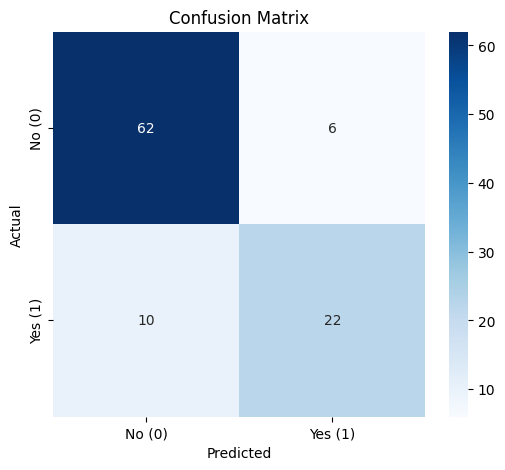

In [12]:
# Visualize the confusion matrix as a heatmap for easier reading
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Step 9: Compute Performance Metrics

From the confusion matrix we derive four key metrics:

**Accuracy** = (TP + TN) / (TP + TN + FP + FN)
> Out of all predictions, how many were correct? Best when classes are balanced.

**Error Rate** = (FP + FN) / (TP + TN + FP + FN) = 1 − Accuracy
> Out of all predictions, how many were wrong?

**Precision** = TP / (TP + FP)
> Of all the times the model predicted "Yes", how many were actually "Yes"? Important when false alarms are costly.

**Recall (Sensitivity)** = TP / (TP + FN)
> Of all the actual "Yes" cases, how many did the model catch? Important when missing positives is costly.

In [13]:
# Compute each metric manually from the confusion matrix values
total = TP + TN + FP + FN

accuracy = (TP + TN) / total
error_rate = (FP + FN) / total
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(f"Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Error Rate : {error_rate:.4f}  ({error_rate*100:.2f}%)")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")

Accuracy   : 0.8400  (84.00%)


Error Rate : 0.1600  (16.00%)
Precision  : 0.7857
Recall     : 0.6875


In [14]:
# Cross-check using sklearn's built-in functions — should match the manual values
print(f"Accuracy  (sklearn): {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (sklearn): {precision_score(y_test, y_pred):.4f}")
print(f"Recall    (sklearn): {recall_score(y_test, y_pred):.4f}")

Accuracy  (sklearn): 0.8400
Precision (sklearn): 0.7857
Recall    (sklearn): 0.6875


In [15]:
# classification_report() gives precision, recall, and F1 for both classes at once
print("Classification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Not Purchased (0)', 'Purchased (1)']))

Classification Report:


                   precision    recall  f1-score   support

Not Purchased (0)       0.86      0.91      0.89        68
    Purchased (1)       0.79      0.69      0.73        32

         accuracy                           0.84       100
        macro avg       0.82      0.80      0.81       100
     weighted avg       0.84      0.84      0.84       100



## Conclusion

We built a Logistic Regression classifier to predict whether a user would purchase a product based on their Age and Estimated Salary.

**Workflow:** Load → Split → Scale → Train (`fit`) → Predict (`predict`) → Confusion Matrix → Metrics.

**Results from the confusion matrix:**
- **TP / TN** tell us how often the model got things right.
- **FP / FN** tell us how it got things wrong.
- **Accuracy** is the headline number, but **precision** and **recall** matter more when the cost of a false alarm differs from the cost of a missed case.

In an advertising context: high **recall** means we catch most likely buyers (good for revenue); high **precision** means we don't waste ads on uninterested users (good for cost efficiency).